<div style="background-image: url('https://www.dropbox.com/scl/fi/nwtuyf23tzyuq9gfan3oc/mcnair.jpg?rlkey=4t1of5cy6bfgxn6xck7yu9hvo&dl=1'); background-size: cover; background-position: center; height: 300px; display: flex; align-items: center; justify-content: center; color: white; text-shadow: 2px 2px 4px rgba(0,0,0,0.7); margin-bottom: 20px; position: relative;">
  <h1 style="text-align: center; font-size: 2.5em; margin: 0;">JGSB Python Workshop <br> Part 14: Neural Networks </h1>
  <div style="position: absolute; bottom: 10px; left: 15px; font-size: 0.9em; color: white; text-shadow: 2px 2px 4px rgba(0,0,0,0.7);">
    Authored by Kerry Back
  </div>
  <div style="position: absolute; bottom: 10px; right: 15px; text-align: right; font-size: 0.9em; color: white; text-shadow: 2px 2px 4px rgba(0,0,0,0.7);">
    Rice University, 2025
  </div>
</div>

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducible results
np.random.seed(42)

### Overview

We will illustrate machine learning with python by training and testing a neural network for image classification.  

Gemini will do all the work.

Following the illustration, there is a brief explanation of how neural networks work.

### Task

Classify hand-written numbers (digits 0 through 9).  This is a simple task and is a standard example for introducing machine learning concepts.

The data is in the scikit-learn library and is loaded and described in the next cell.

The original handwritten digits were pixelated into 64 pixels (8 x 8).  Each observation in the data set consists of 65 numbers: the true digit and the darkness values of each of the 64 pixels.  The darkness values range from 0 (white = no ink) to 16 (black = heavy ink).

Digits Dataset:
  Total samples: 1,797
  Features per sample: 64 (8×8 pixels)
  Classes: 10 (digits 0-9)
  Feature range: [0.0, 16.0]


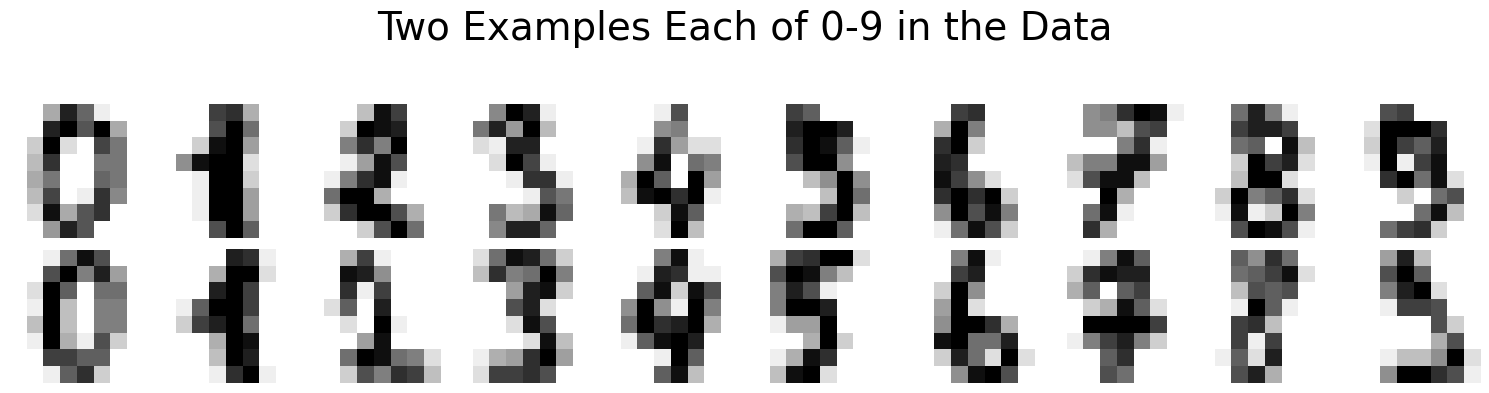

In [ ]:
# Load the digits dataset
digits = load_digits()
X = digits.data  # 8x8 images flattened to 64 features
y = digits.target  # Digit labels 0-9

print(f"Digits Dataset:")
print(f"  Total samples: {X.shape[0]:,}")
print(f"  Features per sample: {X.shape[1]} (8×8 pixels)")
print(f"  Classes: {len(np.unique(y))} (digits 0-9)")
print(f"  Feature range: [{X.min():.1f}, {X.max():.1f}]")

# Show some example digits
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for digit in range(10):
    # Find first occurrence of each digit
    idx = np.where(y == digit)[0][0]
    
    # Original image
    axes[0, digit].imshow(X[idx].reshape(8, 8), cmap='gray_r')
    axes[0, digit].axis('off')
    
    # Show another example
    idx2 = np.where(y == digit)[0][1]  # Second occurrence
    axes[1, digit].imshow(X[idx2].reshape(8, 8), cmap='gray_r')
    axes[1, digit].axis('off')

plt.suptitle('Two Examples Each of 0-9 in the Data', fontsize=28, y=1.02)
plt.tight_layout()
plt.show()


### Exercise

**1.** Ask Gemini to do a train-test split on X and y defined in the previous cell.
**2.** Ask Gemini to train a multilayer perceptron on the training data to predict y from X.
**3.** Ask Gemini to evaluate the performance of the model on the test data.
**4.** Ask Gemini to create and explain the confusion matrix for both the training data and the test data.
**5.** Ask Gemini for suggestions on how to improve the model.
**6.** Ask Gemini to implement at least one of the situations and repeat #3 and #4.

### Understanding Neural Networks: A Simple Example

Imagine you're analyzing customer data and want to predict purchase behavior. You have:
- **Input 1 (x₁)**: Customer age (normalized)
- **Input 2 (x₂)**: Customer income (normalized) 
- **Target**: 1 if customer purchases, 0 if not

For our example, we'll create the target values by assuming customers usually purchase when `age + income ≥ 0` (after normalization).  But, we'll assume this rule does not always hold by adding some noise.

The following cell generates some data and illustrates it.

Customer Data Sample:
   age_normalized  income_normalized  purchase
0       -0.501840           0.568127         1
1        1.802857          -1.663440         1
2        0.927976          -1.353485         1
3        0.394634           1.594217         1
4       -1.375925           0.425716         0


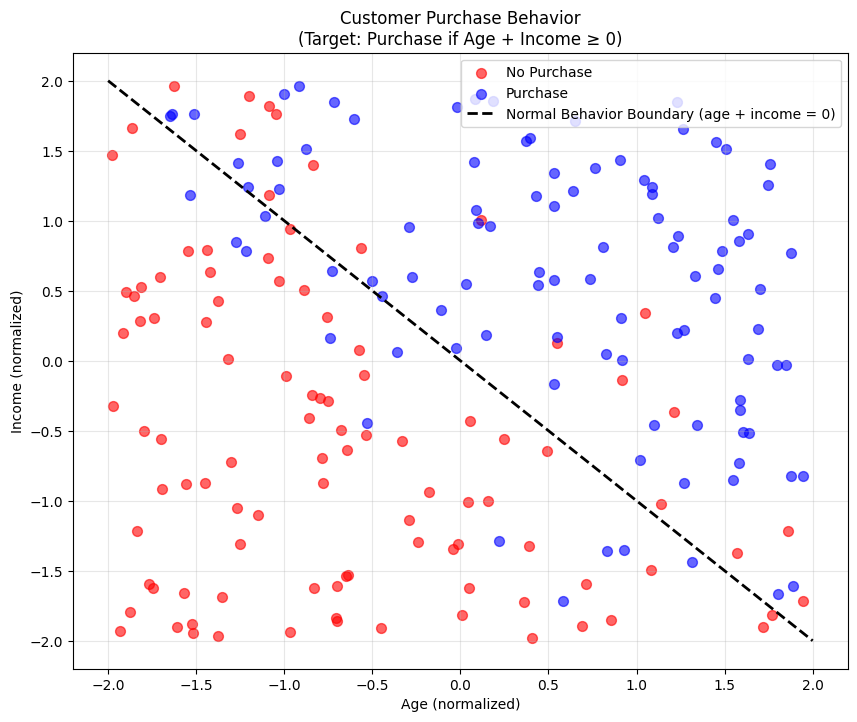


Data Summary:
Total customers: 200
Customers who purchased: 100 (50.0%)
Customers who didn't purchase: 100 (50.0%)


In [25]:
# Generate sample customer data
np.random.seed(42)
n_customers = 200

# Generate random age and income (normalized to range [-2, 2])
x1_age = np.random.uniform(-2, 2, n_customers)
x2_income = np.random.uniform(-2, 2, n_customers)

# True target: purchase if age + income >= 0 (with some noise)
noise = np.random.normal(0, 1, n_customers)  # Add realistic noise
true_score = x1_age + x2_income + noise
y_purchase = (true_score >= 0).astype(int)

# Create DataFrame for easy viewing
customer_data = pd.DataFrame({
    'age_normalized': x1_age,
    'income_normalized': x2_income, 
    'purchase': y_purchase
})

print("Customer Data Sample:")
print(customer_data.head())

# Visualize the data
plt.figure(figsize=(10, 8))
colors = ['red', 'blue']
labels = ['No Purchase', 'Purchase']

for i in [0, 1]:
    mask = y_purchase == i
    plt.scatter(x1_age[mask], x2_income[mask], c=colors[i], alpha=0.6, 
               label=labels[i], s=50)

# Draw the true decision boundary
x_line = np.linspace(-2, 2, 100)
y_line = -x_line  # age + income = 0 => income = -age
plt.plot(x_line, y_line, 'k--', linewidth=2, label='Normal Behavior Boundary (age + income = 0)')

plt.xlabel('Age (normalized)')
plt.ylabel('Income (normalized)')
plt.title('Customer Purchase Behavior\n(Target: Purchase if Age + Income ≥ 0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nData Summary:")
print(f"Total customers: {n_customers}")
print(f"Customers who purchased: {np.sum(y_purchase)} ({np.mean(y_purchase):.1%})")
print(f"Customers who didn't purchase: {n_customers - np.sum(y_purchase)} ({1-np.mean(y_purchase):.1%})")

### Multi-Layer Perceptron Architecture

Now let's build a neural network to learn this pattern. Our network will have:

- **Input Layer**: 2 neurons (age, income)
- **Hidden Layer**: 3 neurons (to learn complex patterns)
- **Output Layer**: 1 neuron (probability of purchase)

Neural Network Structure Visualization:


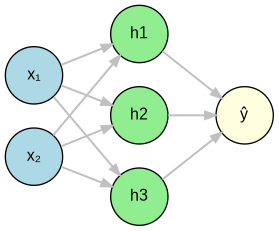


### Key Concepts
- **Weights (W)**: Control the strength of connections between neurons
- **Biases (b)**: Allow neurons to fire even when inputs are zero
- **Activation Function**: Sigmoid function to convert outputs to probabilities
- **Forward Propagation**: Data flows from input to output
- **Backpropagation**: Errors flow backward to update weights

### Network Parameters
• Total connections: 2×3 + 3×1 = 9 weights
• Total biases: 3 + 1 = 4 biases
• Total parameters: 13


In [ ]:
# Visualize the network structure
from IPython.display import Image, display
import os

# Try to display the network diagram
if os.path.exists('../images/neural_network_simple.png'):
    # Local file exists
    print("\nNeural Network Structure Visualization:")
    display(Image('../images/neural_network_simple.png'))
else:
    # Use GitHub URL for Colab
    try:
        from IPython.display import Image as URLImage
        # Update this URL after pushing to GitHub
        github_url = "https://raw.githubusercontent.com/YOUR_USERNAME/YOUR_REPO/main/images/neural_network_simple.png"
        print("\nNeural Network Structure Visualization:")
        print("(Note: Update the GitHub URL in the code after pushing to your repository)")
        # display(URLImage(url=github_url))
    except:
        pass
    

print("\n### Key Concepts")
print("- **Weights (W)**: Control the strength of connections between neurons")
print("- **Biases (b)**: Allow neurons to fire even when inputs are zero")
print("- **Activation Function**: Sigmoid function to convert outputs to probabilities")
print("- **Forward Propagation**: Data flows from input to output")
print("- **Backpropagation**: Errors flow backward to update weights")

print("\n### Network Parameters")
print("• Total connections: 2×3 + 3×1 = 9 weights")
print("• Total biases: 3 + 1 = 4 biases")
print("• Total parameters: 13")